In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import seaborn as sns
import networkx as nx

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [2]:
from scipy.stats import ks_2samp, mannwhitneyu, levene
from scipy.stats import chi2_contingency

In [3]:
kp = pd.read_csv("../../data/kpneumo/kpneumoniae_data_2023.tsv", sep="\t")
pa = pd.read_csv("../../data/paeruginosa/paeruginosa_data_2023.tsv", sep="\t")
ec = pd.read_csv("../../data/ecoli/ecoli_data_2023.tsv", sep="\t")

df = pd.read_csv("../../data/germany_combined_data_counts.tsv", sep="\t")

In [4]:
skp = pd.read_csv("../../data/snp-dists_klebsiella.tsv", sep="\t", header=None)
spa = pd.read_csv("../../data/snp-dists_pseudomonas.tsv", sep="\t", header=None)
sec = pd.read_csv("../../data/snp-dists_ecoli.tsv", sep="\t", header=None)

tekp = pd.read_csv("../../data/kpneumo/te_merged.tsv", sep="\t")
tepa = pd.read_csv("../../data/paeruginosa/te_merged.tsv", sep="\t")
teec = pd.read_csv("../../data/ecoli/te_merged.tsv", sep="\t")

<ipython-input-4-46a263c6e302>:5: DtypeWarning: Columns (2,3,4,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  tekp = pd.read_csv("../../data/kpneumo/te_merged.tsv", sep="\t")
<ipython-input-4-46a263c6e302>:6: DtypeWarning: Columns (2,3,4,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  tepa = pd.read_csv("../../data/paeruginosa/te_merged.tsv", sep="\t")
<ipython-input-4-46a263c6e302>:7: DtypeWarning: Columns (2,3,4,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  teec = pd.read_csv("../../data/ecoli/te_merged.tsv", sep="\t")


In [5]:
tekp = tekp.iloc[1:].copy()
tepa = tepa.iloc[1:].copy()
teec = teec.iloc[1:].copy()   

In [6]:
periods = {
    "pre-pandemic period": ("2019-01-01", "2020-03-31"),
    "acute phase of the pandemic period": ("2020-04-01", "2021-03-31"),
    "transition phase of the pandemic period": ("2021-04-01", "2022-03-31"),
    "post-pandemic period": ("2022-04-01", "2023-12-31")
}

In [7]:
color_mapping = {
    "pre-pandemic period": "#75bbfd",
    "acute phase of the pandemic period": "#ffb07c",
    "transition phase of the pandemic period": "#e2ca76",
    "post-pandemic period": "#029386"
}

In [8]:
def update_transmission_status(df1, df2):
    # Ensure transmission_180d is numeric
    df1["transmission_180d"] = pd.to_numeric(df1["transmission_180d"], errors="coerce").fillna(0).astype(int)

    # Create a mapping of sample1 to max transmission_180d value
    transmission_mapping = df1.groupby("sample1")["transmission_180d"].max()

    # Update df2 with transmission status
    df2["transmission_180d"] = df2["sampleid"].map(lambda x: 1 if transmission_mapping.get(x, 0) == 1 else 0)

    return df2

In [9]:
update_transmission_status(tekp, kp)
update_transmission_status(teec, ec)
update_transmission_status(tepa, pa)

,sampleid,species_identified,samplingdate,collection,hospital_loc,pat_id,isolation_source_categ,sex,age_bin,isolation_source,...,acquisition,covid_isolation,postalcode_area,ward_id,infection_type,origin_pat,ST,SC,species,transmission_180d
0,1085_F1S1R3D1B1P5A07,Pseudomonas aeruginosa,2022-08-18,MHH,Germany,8f09e275f51f79c6dbe9f8d3885bba8d,human,F,"(20, 30)",Swab specimen from oropharynx (specimen),...,community,0.0,38.0,NaN,other,Germany,-,12,NaN,1
1,1085_F1S1R3D1B1P5A12,Pseudomonas aeruginosa,2022-08-22,MHH,Germany,968cea793b64f872a9d813a7221b4d13,human,F,"(60, 70)",Swab from deep wound (specimen),...,nosocomial,0.0,31.0,NaN,other,Germany,1284,125,NaN,0
2,1085_F1S1R3D1B1P5B07,Pseudomonas aeruginosa,2022-08-18,MHH,Germany,62d612484c39f449f3adab20b63b679b,human,M,"(20, 30)",Sputum specimen (specimen),...,community,0.0,38.0,NaN,other,Germany,-,12,NaN,1
3,1085_F1S1R3D1B1P5C02,Pseudomonas aeruginosa,2022-08-21,MHH,Germany,41167584c3fefecd6011524a5e621aff,human,F,"(40, 50)",Urine specimen obtained via indwelling urinary...,...,nosocomial,0.0,29.0,NaN,putative UTI,Germany,381,24,NaN,0
4,1085_F1S1R3D1B1P5C03,Pseudomonas aeruginosa,2022-08-19,MHH,Germany,272b2c2d0e79fc7f83fe6c80c92b69ca,human,F,"(60, 70)",Swab from surgical wound (specimen),...,nosocomial,0.0,38.0,NaN,other,Germany,-,11_108,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8396,F1S1R3D1B2P1C02,NaN,2022-08-22 00:00:00,MHH,NaN,41bde6fcb790ebcc37703ed51de19f14,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,mhh_74,NaN,NaN,870,NaN,Pseudomonas aeruginosa,0
8397,F1S1R3D1B1P5A12,NaN,2022-08-22 00:00:00,MHH,NaN,968cea793b64f872a9d813a7221b4d13,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,mhh_71,NaN,NaN,1284,125,Pseudomonas aeruginosa,0
8398,F1S1R3D1B1P5D12,NaN,2022-08-22 00:00:00,MHH,NaN,968cea793b64f872a9d813a7221b4d13,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,mhh_71,NaN,NaN,1284,125,Pseudomonas aeruginosa,0
8399,F1S1R3D1B1P5C10,NaN,2022-08-22 00:00:00,MHH,NaN,9770514bea1592156be749437786b85b,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,mhh_41,NaN,NaN,564,130,Pseudomonas aeruginosa,0


In [10]:
kp["samplingdate"] = pd.to_datetime(kp["samplingdate"], errors="coerce").dt.strftime("%Y-%m-%d")
pa["samplingdate"] = pd.to_datetime(pa["samplingdate"], errors="coerce").dt.strftime("%Y-%m-%d")
ec["samplingdate"] = pd.to_datetime(ec["samplingdate"], errors="coerce").dt.strftime("%Y-%m-%d")

In [11]:
kp.head(2)

,sampleid,species,samplingdate,collection,hospital_loc,isolation_source_categ,sex,Consent,acquisition,covid_isolation,...,virulence_score,resistance_score,ST_kleborate,age_bin,isolation_source,infection_type,pat_id,ST,SC,transmission_180d
0,ERR10039993,Klebsiella pneumoniae,2016-09-22,SRA,Spain,human,NaN,public,NaN,NaN,...,1.0,2.0,ST101-2LV,NaN,NaN,NaN,NaN,-,9,1
1,ERR10039997,Klebsiella pneumoniae,2016-12-13,SRA,Spain,human,NaN,public,NaN,NaN,...,0.0,1.0,ST15-1LV,NaN,NaN,NaN,NaN,-,2_195,0


In [12]:
kp_tt = kp[["sampleid", "samplingdate", "collection", "transmission_180d", "pat_id"]]
pa_tt = pa[["sampleid", "samplingdate", "collection", "transmission_180d", "pat_id"]]
ec_tt = ec[["sampleid", "samplingdate", "collection", "transmission_180d", "pat_id"]]

In [13]:
def plot_transmission_frequency(df):
    df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
    df['year_month'] = df['samplingdate'].dt.to_period('M')

    sample_counts = df.groupby(['year_month', 'collection'])['transmission_180d'].sum().unstack(fill_value=0)

    colors = {'MHH': 'orange', 'CPH': '#4b006e', 'SRA': '#008080'}  # Teal for SRA

    fig, ax = plt.subplots(figsize=(20, 4))

    # Plot stacked bar chart
    sample_counts.plot(kind='bar', stacked=True, width=0.8, 
                       color=[colors.get(col, 'gray') for col in sample_counts.columns], ax=ax)

    # Adjust x-axis ticks to show every 6 months
    ax.set_xticks(range(0, len(sample_counts.index), 6))
    ax.set_xticklabels(sample_counts.index.astype(str)[::6], rotation=45)

    # Labels and title
    ax.set_xlabel("Sampling Month")
    ax.set_ylabel("Transmission Count")
    ax.set_title("Transmission Over Time (Per Month)")
    ax.legend(title="Collection", facecolor="white")

    plt.show()

<ipython-input-13-85e247771930>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
<ipython-input-13-85e247771930>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['samplingdate'].dt.to_period('M')
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: G

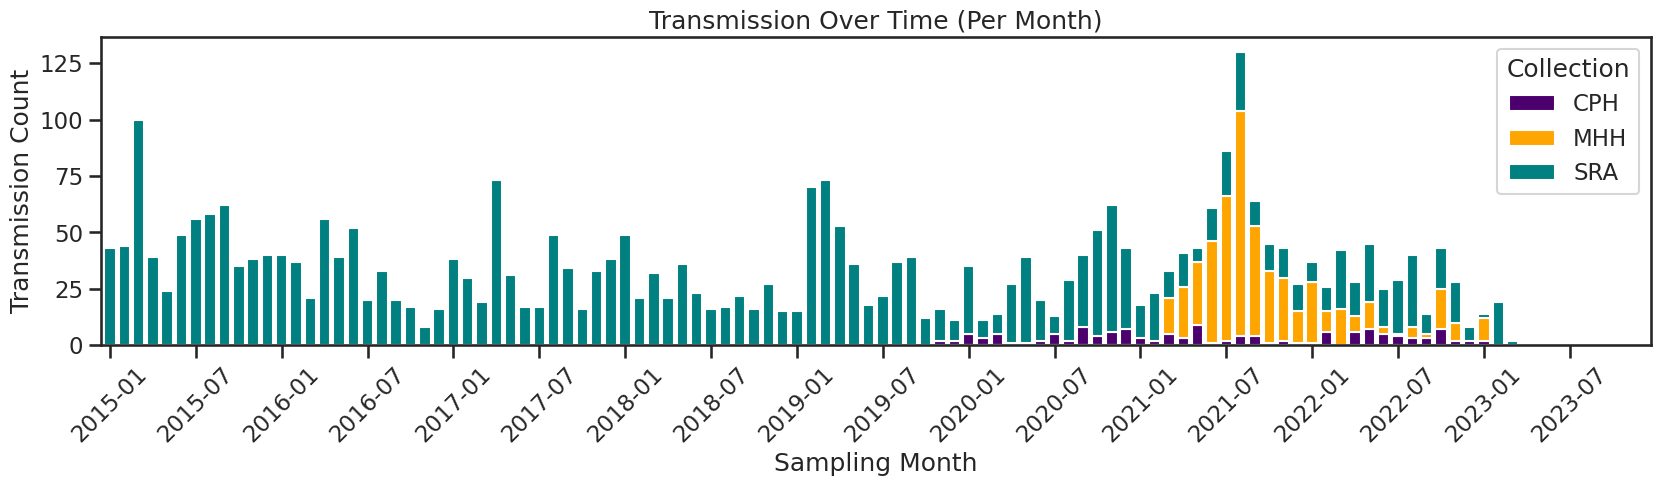

<ipython-input-13-85e247771930>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
<ipython-input-13-85e247771930>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['samplingdate'].dt.to_period('M')
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: G

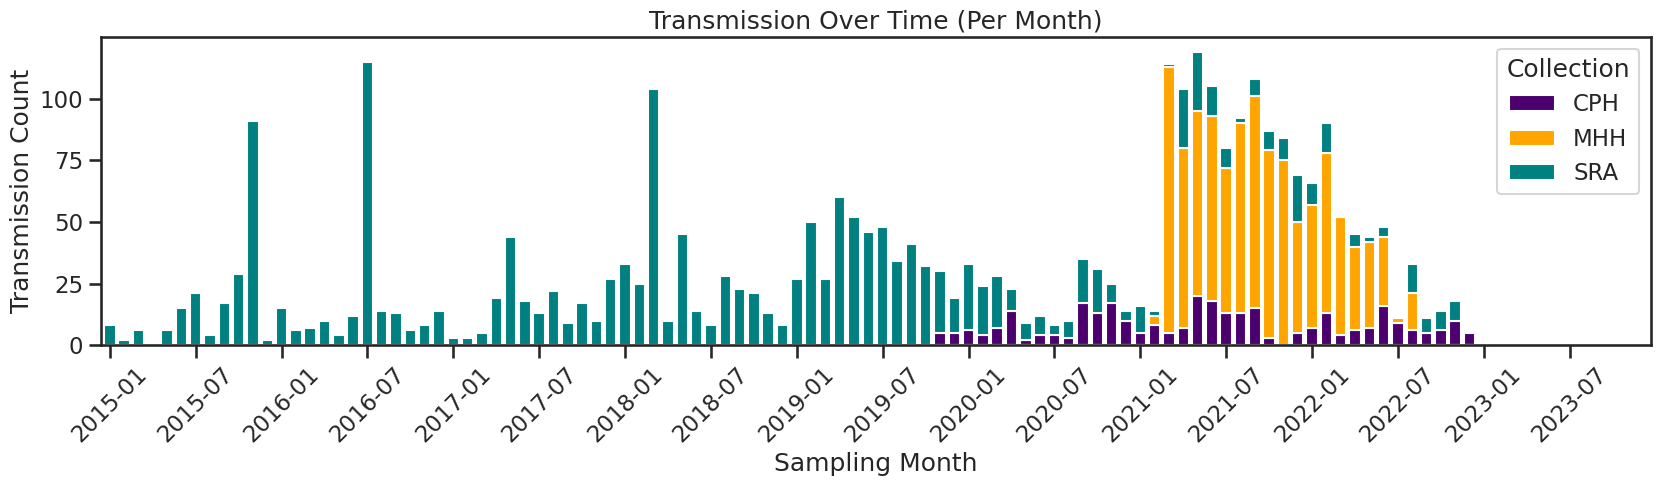

<ipython-input-13-85e247771930>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
<ipython-input-13-85e247771930>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['samplingdate'].dt.to_period('M')
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: G

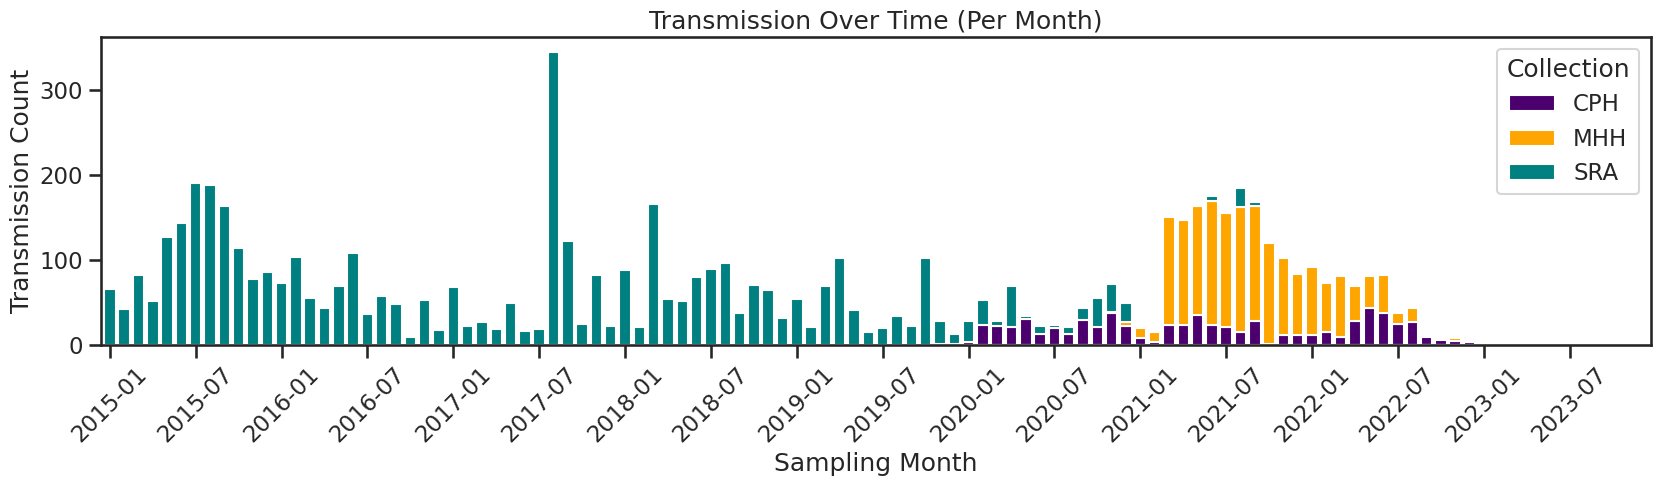

In [14]:
plot_transmission_frequency(kp_tt)
plot_transmission_frequency(pa_tt)
plot_transmission_frequency(ec_tt)

In [15]:
def plot_normal_transmission_frequency(df, sp=""):
    # Convert to datetime and extract year-month period
    df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
    df['year_month'] = df['samplingdate'].dt.to_period('M')

    # Filter data from October 2019 onwards
    df = df[df['year_month'] >= '2019-10']

    # Assign a unique identifier to NaN values in 'pat_id'
    nan_mask = df['pat_id'].isna()
    df.loc[nan_mask, 'pat_id'] = ['unknown_patient_' + str(i) for i in range(nan_mask.sum())]

    # Drop duplicate transmissions per patient per month per collection
    df_unique = df.drop_duplicates(subset=['year_month', 'collection', 'pat_id'])

    # Count unique patient transmissions per month and collection
    sample_counts = df_unique.groupby(['year_month', 'collection'])['transmission_180d'].sum().unstack(fill_value=0)

    # Count total unique patients sampled per month
    total_patients_per_month = df_unique.groupby('year_month')['pat_id'].nunique()

    # Compute percentage of transmissions per total sampled patients per month
    percentage_counts = (sample_counts.div(total_patients_per_month, axis=0) * 100).fillna(0)

    # Define colors for collections
    colors = {'MHH': 'orange', 'CPH': '#4b006e', 'SRA': '#008080'}  # Teal for SRA

    # Create figure and axis with correct size
    fig, ax = plt.subplots(figsize=(20, 4))

    # Plot stacked bar chart
    percentage_counts.plot(kind='bar', stacked=True, width=0.8, 
                           color=[colors.get(col, 'gray') for col in percentage_counts.columns], ax=ax)

    # Adjust x-axis ticks to show every 6 months
    ax.set_xticks(range(0, len(percentage_counts.index), 6))
    ax.set_xticklabels(percentage_counts.index.astype(str)[::6], rotation=45)

    # Labels and title
    ax.set_xlabel("Sampling Month")
    ax.set_ylabel("Transmission %")
    ax.set_title(f"Normalized Transmission Counts for {sp}")
    ax.legend(title="Collection", facecolor="white")

    plt.show()

<ipython-input-15-f98b1c6b6def>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
<ipython-input-15-f98b1c6b6def>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['samplingdate'].dt.to_period('M')
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: G

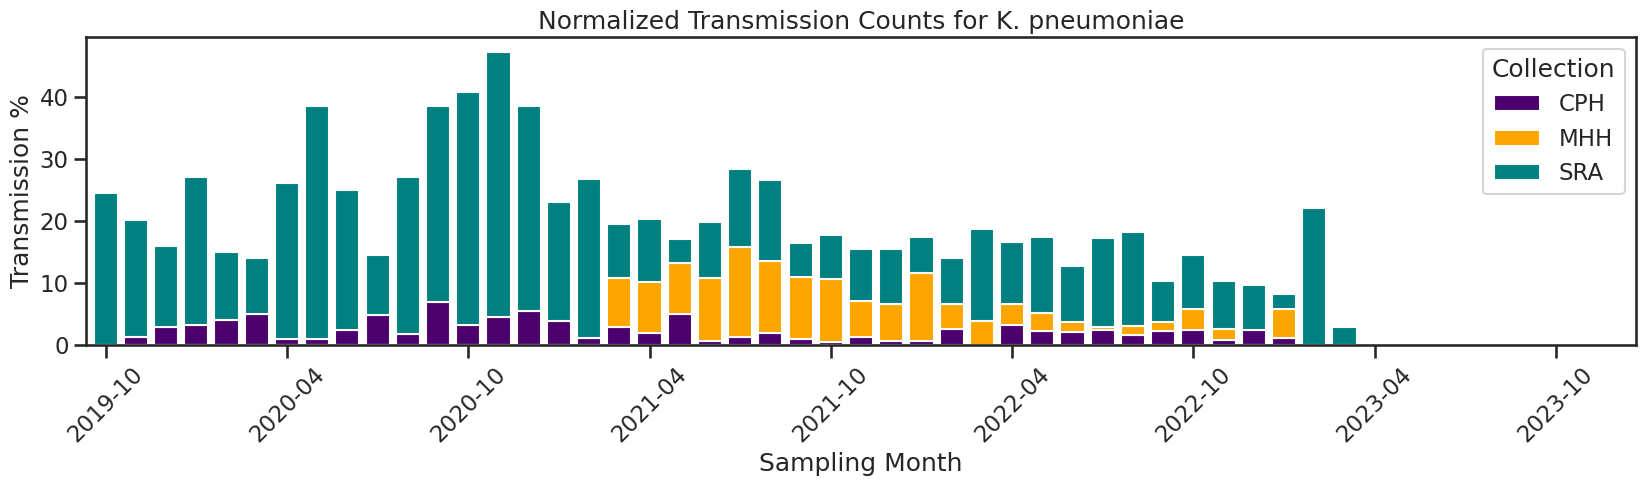

<ipython-input-15-f98b1c6b6def>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
<ipython-input-15-f98b1c6b6def>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['samplingdate'].dt.to_period('M')
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: G

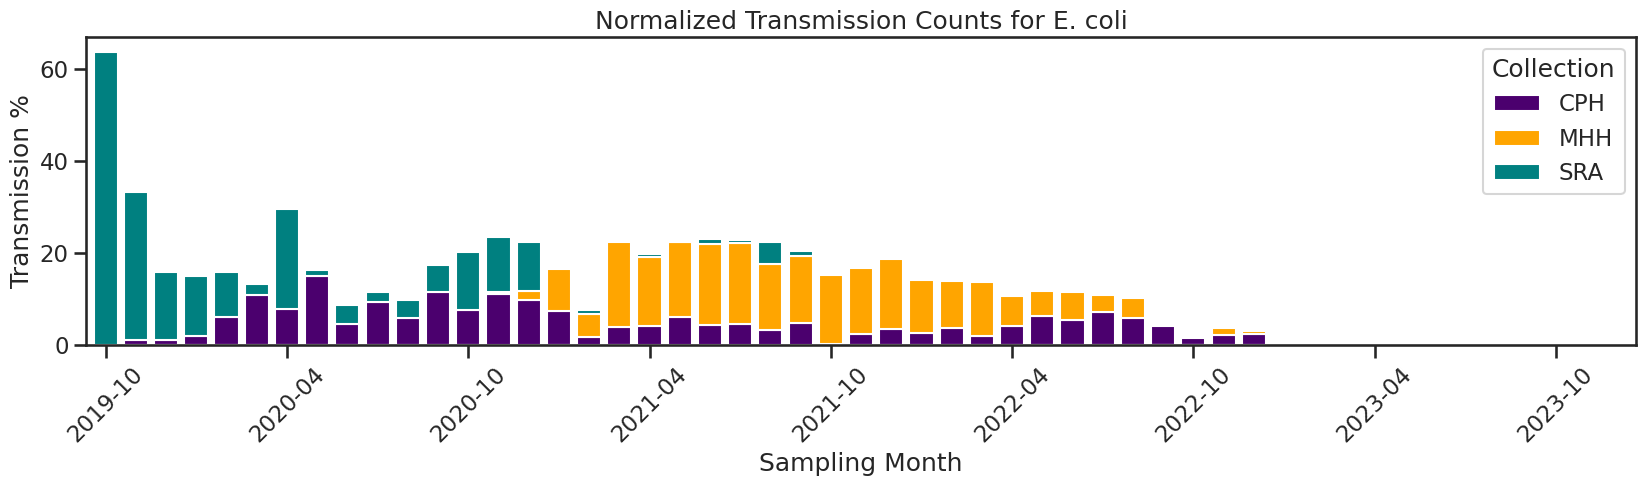

<ipython-input-15-f98b1c6b6def>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
<ipython-input-15-f98b1c6b6def>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['samplingdate'].dt.to_period('M')
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: G

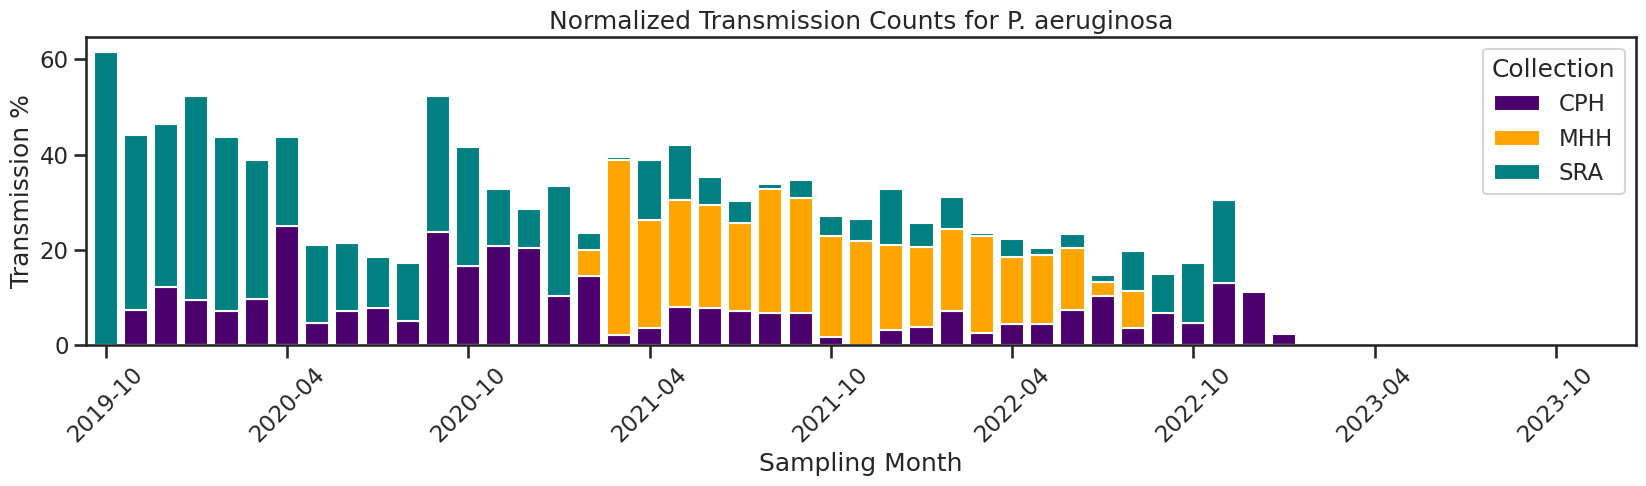

In [16]:
plot_normal_transmission_frequency(kp_tt, sp="K. pneumoniae")
plot_normal_transmission_frequency(ec_tt, sp="E. coli")
plot_normal_transmission_frequency(pa_tt, sp="P. aeruginosa")

In [17]:
tekp = tekp.merge(kp[["sampleid", 'pat_id']], left_on='sample1', right_on='sampleid', how='left')
teec = teec.merge(ec[["sampleid", 'pat_id']], left_on='sample1', right_on='sampleid', how='left')
tepa = tepa.merge(pa[["sampleid", 'pat_id']], left_on='sample1', right_on='sampleid', how='left')

tekp.rename(columns={"pat_id":"pat_id1"}, inplace=True)
tepa.rename(columns={"pat_id":"pat_id1"}, inplace=True)
teec.rename(columns={"pat_id":"pat_id1"}, inplace=True)

tekp = tekp.merge(kp[["sampleid", 'pat_id']], left_on='sample2', right_on='sampleid', how='left')
teec = teec.merge(ec[["sampleid", 'pat_id']], left_on='sample2', right_on='sampleid', how='left')
tepa = tepa.merge(pa[["sampleid", 'pat_id']], left_on='sample2', right_on='sampleid', how='left')

tekp.rename(columns={"pat_id":"pat_id2"}, inplace=True)
tepa.rename(columns={"pat_id":"pat_id2"}, inplace=True)
teec.rename(columns={"pat_id":"pat_id2"}, inplace=True)

tekp = tekp.merge(kp[["sampleid", 'collection']], left_on='sample2', right_on='sampleid', how='left')
teec = teec.merge(ec[["sampleid", 'collection']], left_on='sample2', right_on='sampleid', how='left')
tepa = tepa.merge(pa[["sampleid", 'collection']], left_on='sample2', right_on='sampleid', how='left')

tekp.rename(columns={"collection":"collection2"}, inplace=True)
tepa.rename(columns={"collection":"collection2"}, inplace=True)
teec.rename(columns={"collection":"collection2"}, inplace=True)

tekp = tekp.merge(kp[["sampleid", 'collection']], left_on='sample1', right_on='sampleid', how='left')
teec = teec.merge(ec[["sampleid", 'collection']], left_on='sample1', right_on='sampleid', how='left')
tepa = tepa.merge(pa[["sampleid", 'collection']], left_on='sample1', right_on='sampleid', how='left')

tekp.rename(columns={"collection":"collection1"}, inplace=True)
tepa.rename(columns={"collection":"collection1"}, inplace=True)
teec.rename(columns={"collection":"collection1"}, inplace=True)

tekp_h = tekp[(tekp.collection1 != "SRA") & (tekp.collection2 != "SRA")]
tepa_h = tepa[(tepa.collection1 != "SRA") & (tepa.collection2 != "SRA")]
teec_h = teec[(teec.collection1 != "SRA") & (teec.collection2 != "SRA")]

<ipython-input-17-48deb4801cb9>:25: FutureWarning: Passing 'suffixes' which cause duplicate columns {'sampleid_x'} in the result is deprecated and will raise a MergeError in a future version.
  tekp = tekp.merge(kp[["sampleid", 'collection']], left_on='sample1', right_on='sampleid', how='left')
<ipython-input-17-48deb4801cb9>:26: FutureWarning: Passing 'suffixes' which cause duplicate columns {'sampleid_x'} in the result is deprecated and will raise a MergeError in a future version.
  teec = teec.merge(ec[["sampleid", 'collection']], left_on='sample1', right_on='sampleid', how='left')
<ipython-input-17-48deb4801cb9>:27: FutureWarning: Passing 'suffixes' which cause duplicate columns {'sampleid_x'} in the result is deprecated and will raise a MergeError in a future version.
  tepa = tepa.merge(pa[["sampleid", 'collection']], left_on='sample1', right_on='sampleid', how='left')


In [18]:
def plot_stacked_bar_with_bins(data, snp_col="snps", binary_col="transmission", bins=30, max_snp=200, vline=20,sp="", name=""):
    """
    Creates a stacked bar plot of SNP counts with bins, limiting to a max SNP value,
    and different alpha levels based on the 'transmission' column.

    Parameters:
    - data (pd.DataFrame): DataFrame containing the data.
    - snp_col (str): Column representing the SNP counts (default: "snps").
    - binary_col (str): Column with binary values (0 or 1) determining alpha level (default: "transmission").
    - bins (int): Number of bins for SNP grouping (default: 30).
    - max_snp (int): Maximum SNP value to include in the plot (default: 200).
    """
    # Convert SNP column to numeric, coerce errors to NaN
    data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
    
    # Drop NaN values caused by non-numeric entries
    data = data.dropna(subset=[snp_col])
    
    # Filter data to limit SNP values
    filtered_data = data[data[snp_col] <= max_snp].copy()

    # Define bin edges and labels (only using last number in bin for xticks)
    bin_edges = np.linspace(0, max_snp, bins + 1)
    bin_labels = [str(int(bin_edges[i+1])) for i in range(len(bin_edges) - 1)]

    # Assign SNP values to bins
    filtered_data["snp_bin"] = pd.cut(filtered_data[snp_col], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # Count occurrences for each bin and transmission status
    grouped_data = filtered_data.groupby(["snp_bin", binary_col]).size().unstack(fill_value=0)

    # Plot setup
    fig, ax = plt.subplots(figsize=(9, 4))

    # Plot transmission = 1 first, so transmission = 0 is on top
    grouped_data[1].plot(kind="bar", stacked=True, ax=ax, color="xkcd:orange", alpha=1, label="Transmission = 1")
    grouped_data[0].plot(kind="bar", stacked=True, ax=ax, color="xkcd:blue", alpha=0.5, label="Transmission = 0")


    # Add a vertical red dotted line at the specified SNP value
    vline_index = np.searchsorted(bin_edges, vline) - 1
    if 0 <= vline_index < len(bin_labels):
        plt.axvline(x=vline_index, color="red", linestyle="dotted", linewidth=2)

    # Labels and aesthetics
    plt.xlabel("SNP Bins", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title(f"{sp}")
    plt.xticks(ticks=np.arange(len(bin_labels)), labels=bin_labels)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.legend(title="", loc="upper right", facecolor="white")
    

    plt.savefig(f'../../out/figures/transmission_proportion_snps_{name}.png',
                dpi=150, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/transmission_proportion_snps_{name}.svg',
               dpi=150, bbox_inches='tight', transparent=True, format='svg')

    # Show plot
    plt.show();

<ipython-input-18-18dcd563382b>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families 

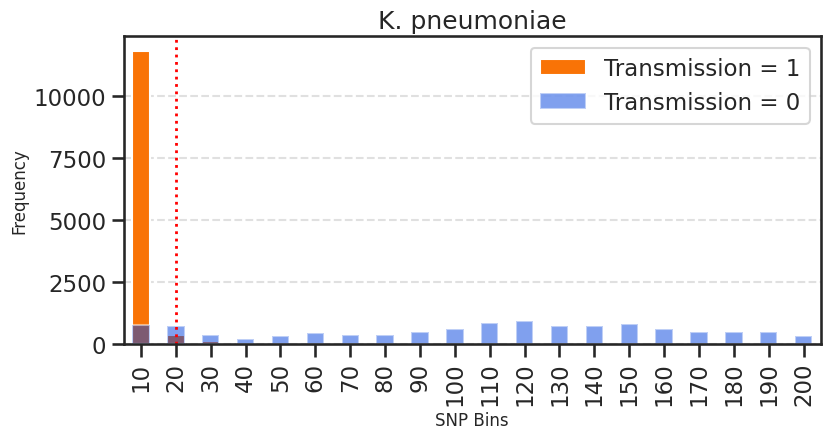

In [19]:
plot_stacked_bar_with_bins(tekp_h, snp_col="snps", binary_col="transmission_180d", bins=20, max_snp=200, sp="K. pneumoniae", name="kp")

<ipython-input-18-18dcd563382b>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families 

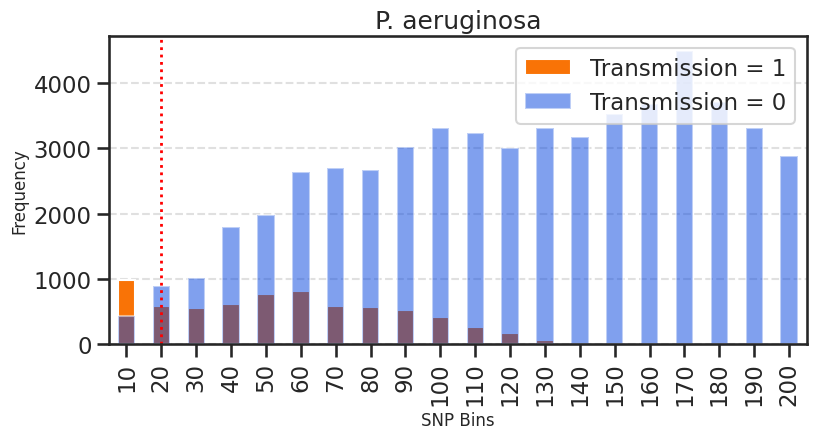

In [20]:
plot_stacked_bar_with_bins(tepa_h, snp_col="snps", binary_col="transmission_180d", bins=20, max_snp=200, sp="P. aeruginosa", name="pa")

<ipython-input-18-18dcd563382b>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families 

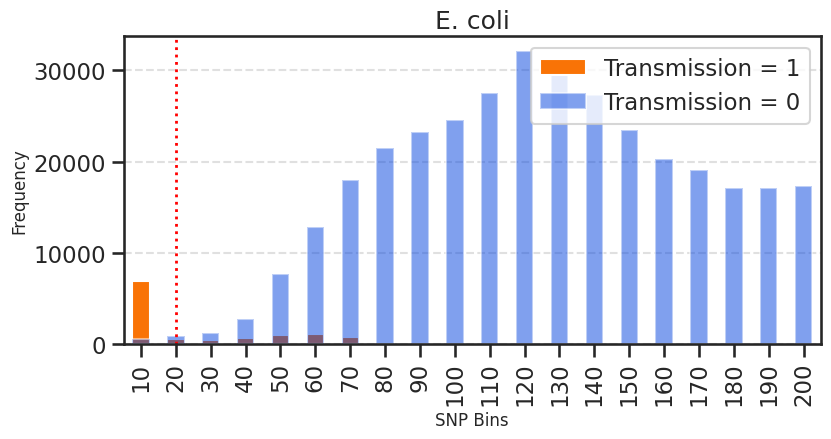

In [21]:
plot_stacked_bar_with_bins(teec_h, snp_col="snps", binary_col="transmission_180d", bins=20, max_snp=200, sp="E. coli", name="ec")

In [22]:
from scipy.stats import gaussian_kde

def plot_smoothed_stacked_proportion(
    data,
    snp_col="snps",
    binary_col="transmission",
    max_snp=200,
    vline=20,
    color="xkcd:blue",
    sp="",
    name=""
):
    """
    Plots smoothed *stacked* proportion curves for SNPs,
    transmission=1 is bottom, transmission=0 stacked on top.
    The y-axis shows proportion (0–1) instead of counts.
    """

    # Convert SNP column
    data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
    data = data.dropna(subset=[snp_col])
    data = data[data[snp_col] <= max_snp]

    # Split data
    snps_1 = data[data[binary_col] == 1][snp_col].values
    snps_0 = data[data[binary_col] == 0][snp_col].values

    # Domain for smoothing
    x_vals = np.linspace(0, max_snp, 800)

    # KDE scaled to counts (then normalized to proportion)
    def kde_to_proportion(arr):
        if len(arr) < 2:
            return np.zeros_like(x_vals)
        kde = gaussian_kde(arr)
        y = kde(x_vals)
        return y

    y1 = kde_to_proportion(snps_1)
    y0 = kde_to_proportion(snps_0)

    # Normalize to proportion
    total = y1 + y0
    # Avoid division by zero
    total[total == 0] = 1
    y1_prop = y1 / total
    y0_prop = y0 / total

    fig, ax = plt.subplots(figsize=(4, 3))

    # Plot transmission=1 (bottom)
    ax.fill_between(x_vals, 0, y1_prop, color=color, alpha=1, label="Transmission = 1")
    ax.plot(x_vals, y1_prop, color=color, alpha=1, lw=0)

    # Plot transmission=0 (stacked on top)
    ax.fill_between(x_vals, y1_prop, y1_prop + y0_prop, color=color, alpha=0.3, label="Transmission = 0")
    ax.plot(x_vals, y1_prop + y0_prop, color=color, alpha=0.5, lw=2)

    # Vertical reference line
    ax.axvline(vline, color="black", linestyle="dotted", linewidth=2)

    # Labels and appearance
    ax.set_xlabel("SNPs", fontsize=16)
    ax.set_ylabel("Proportion", fontsize=16)
    ax.set_title(f"{sp}", fontsize=13)
    ax.legend(loc="upper right", facecolor="white")

    # Make 0 appear at bottom-left
    ax.set_xlim(0, max_snp)
    ax.set_ylim(0, 1)  # y-axis is proportion from 0 to 1

    # Save figures
    plt.savefig(
        f'../../out/figures/transmission_smoothed_stacked_proportion_{name}.png',
        dpi=150, bbox_inches='tight', transparent=True
    )
    plt.savefig(
        f'../../out/figures/transmission_smoothed_stacked_proportion_{name}.svg',
        dpi=150, bbox_inches='tight', transparent=True
    )

    plt.show()

<ipython-input-22-783c6185e685>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families 

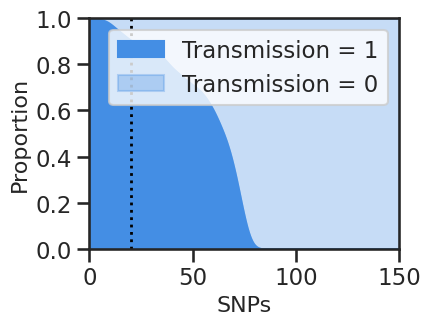

In [23]:
plot_smoothed_stacked_proportion(teec_h, snp_col="snps", binary_col="transmission_180d", max_snp=150, 
                      sp="", name="ec", color="#448ee4")

<ipython-input-22-783c6185e685>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families 

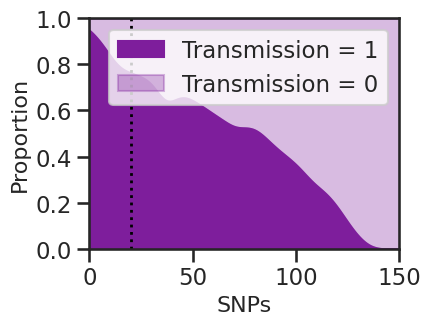

In [24]:
plot_smoothed_stacked_proportion(tepa_h, snp_col="snps", binary_col="transmission_180d", max_snp=150, 
                      sp="", name="pa", color="#7e1e9c")

<ipython-input-22-783c6185e685>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families 

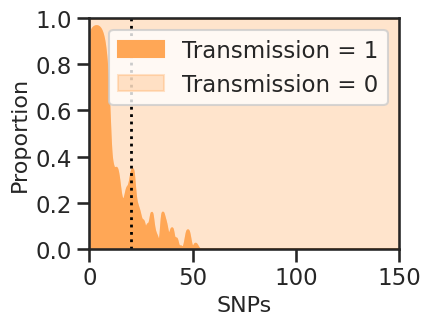

In [25]:
plot_smoothed_stacked_proportion(tekp_h, snp_col="snps", binary_col="transmission_180d", max_snp=150, 
                      sp="", name="kp", color="#ffa756")

In [26]:
def plot_smoothed_stacked_counts(
    data,
    snp_col="snps",
    binary_col="transmission",
    max_snp=200,
    vline=20,
    color="xkcd:blue",
    sp="",
    name=""
):
    """
    Plots smoothed *stacked* count curves for SNPs,
    transmission=1 is bottom, transmission=0 stacked on top.
    """

    # Convert SNP column
    data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
    data = data.dropna(subset=[snp_col])
    data = data[data[snp_col] <= max_snp]

    # Split data
    snps_1 = data[data[binary_col] == 1][snp_col].values
    snps_0 = data[data[binary_col] == 0][snp_col].values

    # Domain for smoothing
    x_vals = np.linspace(0, max_snp, 800)

    # KDE scaled to counts
    def kde_to_counts(arr):
        if len(arr) < 2:
            return np.zeros_like(x_vals)
        kde = gaussian_kde(arr)
        y = kde(x_vals)
        return y * len(arr)

    y1 = kde_to_counts(snps_1)
    y0 = kde_to_counts(snps_0)

    fig, ax = plt.subplots(figsize=(4, 3))

    # Plot transmission=1 (bottom)
    ax.fill_between(x_vals, 0, y1, color=color, alpha=1, label="Transmission = 1")
    ax.plot(x_vals, y1, color=color, alpha=1, lw=0)

    # Plot transmission=0 (stacked on top)
    ax.fill_between(x_vals, y1, y1 + y0, color=color, alpha=0.3, label="Transmission = 0")
    ax.plot(x_vals, y1 + y0, color=color, alpha=0.5, lw=2)

    # Vertical reference line
    ax.axvline(vline, color="grey", linestyle="dotted", linewidth=2)

    # Labels and appearance
    ax.set_xlabel("SNPs", fontsize=16)
    ax.set_ylabel("Total strain-strain counts", fontsize=16)
    ax.set_title(f"", fontsize=13)
    ax.legend(loc="upper right", facecolor="white")
    # Make 0 appear at bottom-left
    ax.set_xlim(0, max_snp)             # x-axis from 0 to max SNP
    ax.set_ylim(0, (y1 + y0).max() * 1.05)  # y-axis from 0 to slightly above max count


    # Save figures
    plt.savefig(
        f'../../out/figures/transmission_smoothed_stacked_counts_{name}.png',
        dpi=150, bbox_inches='tight', transparent=True
    )
    plt.savefig(
        f'../../out/figures/transmission_smoothed_stacked_counts_{name}.svg',
        dpi=150, bbox_inches='tight', transparent=True
    )

    plt.show()

<ipython-input-26-56b13a3f0990>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families 

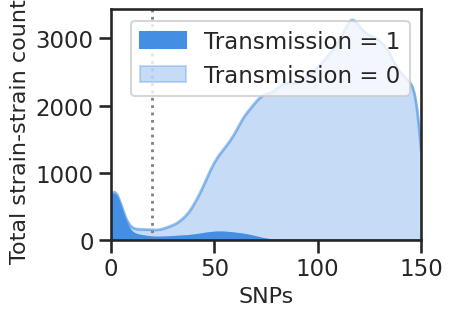

In [27]:
plot_smoothed_stacked_counts(teec_h, snp_col="snps", binary_col="transmission_180d", max_snp=150, 
                      sp="E. coli", name="ec", color="#448ee4")

<ipython-input-26-56b13a3f0990>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families 

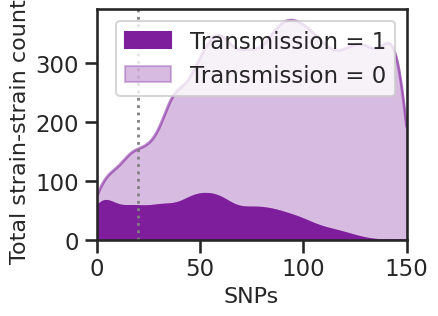

In [28]:
plot_smoothed_stacked_counts(tepa_h, snp_col="snps", binary_col="transmission_180d", max_snp=150, 
                      sp="P. aeruginosa", name="pa", color="#7e1e9c")

<ipython-input-26-56b13a3f0990>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[snp_col] = pd.to_numeric(data[snp_col], errors="coerce")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families 

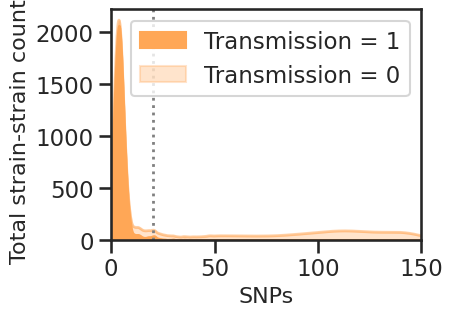

In [29]:
plot_smoothed_stacked_counts(tekp_h, snp_col="snps", binary_col="transmission_180d", max_snp=150, 
                      sp="K. pneumoniae", name="kp", color="#ffa756")

Need to add SC into transmission data, and then look at some SC with multiple transmissions.
Need to plot transmission network for some SC that are within a cluster over time, and their percentage of transmission over time.

In [30]:
tekp = tekp.merge(kp[['sampleid', 'SC']], left_on='sample1', right_on='sampleid', how='left')
teec = teec.merge(ec[['sampleid', 'SC']], left_on='sample1', right_on='sampleid', how='left')
tepa = tepa.merge(pa[['sampleid', 'SC']], left_on='sample1', right_on='sampleid', how='left')
tekp = tekp.merge(kp[['sampleid', 'samplingdate']], left_on='sample1', right_on='sampleid', how='left')
teec = teec.merge(ec[['sampleid', 'samplingdate']], left_on='sample1', right_on='sampleid', how='left')
tepa = tepa.merge(pa[['sampleid', 'samplingdate']], left_on='sample1', right_on='sampleid', how='left')

<ipython-input-30-df19144506f3>:4: FutureWarning: Passing 'suffixes' which cause duplicate columns {'sampleid_x'} in the result is deprecated and will raise a MergeError in a future version.
  tekp = tekp.merge(kp[['sampleid', 'samplingdate']], left_on='sample1', right_on='sampleid', how='left')
<ipython-input-30-df19144506f3>:5: FutureWarning: Passing 'suffixes' which cause duplicate columns {'sampleid_x'} in the result is deprecated and will raise a MergeError in a future version.
  teec = teec.merge(ec[['sampleid', 'samplingdate']], left_on='sample1', right_on='sampleid', how='left')
<ipython-input-30-df19144506f3>:6: FutureWarning: Passing 'suffixes' which cause duplicate columns {'sampleid_x'} in the result is deprecated and will raise a MergeError in a future version.
  tepa = tepa.merge(pa[['sampleid', 'samplingdate']], left_on='sample1', right_on='sampleid', how='left')


# transmission summaries, transmission percentage per species, divided also by MDR or not or virulence/resistance scores

In [31]:
def transmission_summary(df1, df2, df3, df1_name='df1', df2_name='df2', df3_name='df3'):
    cols = ['transmission', 'transmission_180d', "transmission_90d", 'transmission_20SNP']
    
    def percent(df, col):
        return (df[col] == 1).mean() * 100

    data = {
        'metric': cols,
        df1_name: [percent(df1, col) for col in cols],
        df2_name: [percent(df2, col) for col in cols],
        df3_name: [percent(df3, col) for col in cols],
    }

    return pd.DataFrame(data)

In [32]:
t_summ_h = transmission_summary(tekp_h, teec_h, tepa_h, df1_name="K. pneumoniae", df2_name="E. coli", df3_name="P. aeruginosa")

In [34]:
t_summ_h

,metric,K. pneumoniae,E. coli,P. aeruginosa
0,transmission,18.989137,5.611667,20.787923
1,transmission_180d,14.541854,0.357554,3.693057
2,transmission_90d,12.905910,0.195956,0.905994
3,transmission_20SNP,14.943808,0.270736,1.390077


<ipython-input-159-2e18df49a3d2>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["color"] = df_filtered["species"].map(species_colors)
<ipython-input-159-2e18df49a3d2>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["alpha"] = df_filtered["metric"].map(alpha_map)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: 

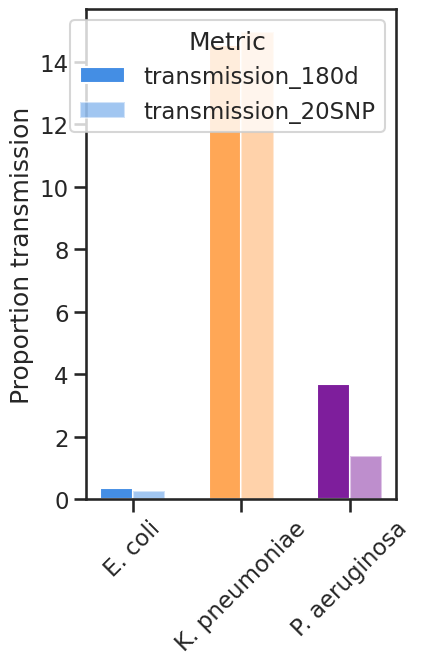

In [159]:
df_melted = t_summ_h.melt(id_vars="metric", var_name="species", value_name="value")
df_filtered = df_melted[df_melted["metric"].isin(["transmission_180d", "transmission_20SNP"])]

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

# Color and alpha mappings
species_order = ["E. coli", "K. pneumoniae", "P. aeruginosa"]
species_colors = {
    "K. pneumoniae": "#ffa756",
    "E. coli": "#448ee4",
    "P. aeruginosa": "#7e1e9c"
}
alpha_map = {
    "transmission_180d": 1.0,
    "transmission_20SNP": 0.5
}
df_filtered["color"] = df_filtered["species"].map(species_colors)
df_filtered["alpha"] = df_filtered["metric"].map(alpha_map)

plt.figure(figsize=(4.5, 7))

# Bar positioning (x-axis now)
x_offset = {"transmission_180d": -0.15, "transmission_20SNP": 0.15}
bar_width = 0.3

# Positions of species on x-axis (integer positions)
x_positions = np.arange(len(species_order))

for metric in ["transmission_180d", "transmission_20SNP"]:
    subset = df_filtered[df_filtered["metric"] == metric]
    for i, species in enumerate(species_order):
        val = subset[subset["species"] == species]["value"].values[0]
        color = species_colors[species]
        alpha = alpha_map[metric]
        plt.bar(
            x=x_positions[i] + x_offset[metric],
            height=val,
            width=bar_width,
            color=color,
            alpha=alpha,
            edgecolor="white",
            label=metric if i == 0 else ""
        )

plt.xticks(x_positions, species_order, rotation=45)
plt.ylabel("Proportion transmission")
plt.xlabel("")
plt.legend(title="Metric", facecolor="white")
plt.tight_layout()

plt.savefig(f'../../out/figures/transmission_proportion_v2.png',
            dpi=150, bbox_inches='tight', transparent=True)
plt.savefig(f'../../out/figures/transmission_proportion_v2.svg',
            dpi=150, bbox_inches='tight', transparent=True, format='svg')

plt.show()

<ipython-input-160-400f211bf8f3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["color"] = df_filtered["species"].map(species_colors)
<ipython-input-160-400f211bf8f3>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["alpha"] = df_filtered["metric"].map(alpha_map)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: 

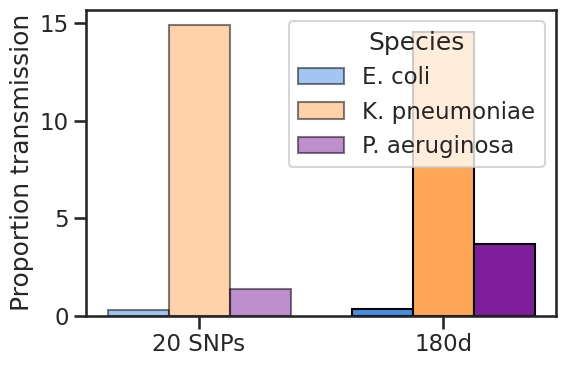

In [160]:
df_melted = t_summ_h.melt(id_vars="metric", var_name="species", value_name="value")
df_filtered = df_melted[df_melted["metric"].isin(["transmission_180d", "transmission_20SNP"])]

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

# Color and alpha mappings
species_order = ["E. coli", "K. pneumoniae", "P. aeruginosa"]
species_colors = {
    "K. pneumoniae": "#ffa756",
    "E. coli": "#448ee4",
    "P. aeruginosa": "#7e1e9c"
}
alpha_map = {
    "transmission_180d": 1.0,
    "transmission_20SNP": 0.5
}

df_filtered["color"] = df_filtered["species"].map(species_colors)
df_filtered["alpha"] = df_filtered["metric"].map(alpha_map)

plt.figure(figsize=(6, 4))

# Bar settings
bar_width = 0.25
metrics_order = ["transmission_20SNP", "transmission_180d"]
group_positions = np.arange(len(metrics_order))  # positions for each metric group

# Offset for species within each group
species_offsets = np.linspace(-bar_width, bar_width, len(species_order))

for i, metric in enumerate(metrics_order):
    subset = df_filtered[df_filtered["metric"] == metric]
    for j, species in enumerate(species_order):
        val = subset[subset["species"] == species]["value"].values[0]
        color = species_colors[species]
        alpha = alpha_map[metric]
        plt.bar(
            x=group_positions[i] + species_offsets[j],
            height=val,
            width=bar_width,
            color=color,
            alpha=alpha,
            edgecolor="black",
            label=species if i == 0 else ""
        )

# X-axis labels centered on each metric group
plt.xticks(group_positions, ["20 SNPs", "180d"])
plt.ylabel("Proportion transmission")
plt.xlabel("")
plt.legend(title="Species", facecolor="white")
plt.tight_layout()

plt.savefig(f'../../out/figures/transmission_proportion_v2.png',
            dpi=150, bbox_inches='tight', transparent=True)
plt.savefig(f'../../out/figures/transmission_proportion_v2.svg',
            dpi=150, bbox_inches='tight', transparent=True, format='svg')

plt.show()

<ipython-input-161-a730e86c9c9a>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["color"] = df_filtered["species"].map(species_colors)
<ipython-input-161-a730e86c9c9a>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["alpha"] = df_filtered["metric"].map(alpha_map)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: 

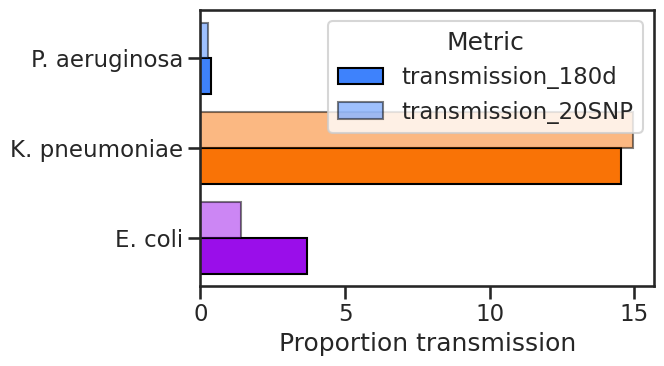

In [161]:
df_melted = t_summ_h.melt(id_vars="metric", var_name="species", value_name="value")
df_filtered = df_melted[df_melted["metric"].isin(["transmission_180d", "transmission_20SNP"])]

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

# Color and alpha mappings
species_order = ["E. coli", "K. pneumoniae", "P. aeruginosa"]
species_colors = {
    "K. pneumoniae": "xkcd:orange",
    "E. coli": "xkcd:dodger blue",
    "P. aeruginosa": "xkcd:violet"
}
alpha_map = {
    "transmission_180d": 1.0,
    "transmission_20SNP": 0.5
}
df_filtered["color"] = df_filtered["species"].map(species_colors)
df_filtered["alpha"] = df_filtered["metric"].map(alpha_map)

# Plot
plt.figure(figsize=(7 , 4))

# Bar positioning
x_offset = {"transmission_180d": -0.2, "transmission_20SNP": 0.2}
bar_height = 0.4

for metric in ["transmission_180d", "transmission_20SNP"]:
    subset = df_filtered[df_filtered["metric"] == metric]
    for i, species in enumerate(species_order):
        val = subset[subset["species"] == species]["value"].values[0]
        color = species_colors[species]
        alpha = alpha_map[metric]
        plt.barh(
            y=len(species_order) - 1 - i + x_offset[metric],  # reversed for top-down order
            width=val,
            height=bar_height,
            color=color,
            alpha=alpha,
            edgecolor="black",
            label=metric if i == 0 else ""
        )

plt.yticks(range(len(species_order)), species_order)
plt.xlabel("Proportion transmission")
plt.ylabel("")
plt.legend(title="Metric", facecolor="white")
plt.tight_layout()

plt.savefig(f'../../out/figures/transmission_proportion.png',
            dpi=150, bbox_inches='tight', transparent=True)
plt.savefig(f'../../out/figures/transmission_proportion.svg',
           dpi=150, bbox_inches='tight', transparent=True, format='svg')

plt.show()

In [162]:
def transmission_per_month_three_species(df1, df2, df3, df1_name='species1', df2_name='species2', df3_name='species3',
                                         date_col='samplingdate', transmission_col='transmission'):
    def prep(df, name):
        df = df.copy()
        df[date_col] = pd.to_datetime(df[date_col])
        df['month'] = df[date_col].dt.to_period('M')
        df['species'] = name
        return df[['month', transmission_col, 'species']]

    combined = pd.concat([
        prep(df1, df1_name),
        prep(df2, df2_name),
        prep(df3, df3_name)
    ])

    result = (
        combined
        .groupby(['species', 'month'])[transmission_col]
        .apply(lambda x: (x == 1).mean() * 100)
        .reset_index(name='transmission_percentage')
    )

    return result

In [163]:
transmission_combined = transmission_per_month_three_species(tekp, teec, tepa, df1_name="K. pneumoniae", df2_name="E. coli", df3_name="P. aeruginosa",
                                    date_col='samplingdate', transmission_col="transmission_180d")

In [164]:
kp_tt_h = kp_tt[kp_tt.collection != "SRA"]
pa_tt_h = pa_tt[pa_tt.collection != "SRA"]
ec_tt_h = ec_tt[ec_tt.collection != "SRA"]

In [165]:
transmission_combined_h = transmission_per_month_three_species(kp_tt_h, ec_tt_h, pa_tt_h, df1_name="K. pneumoniae", df2_name="E. coli", df3_name="P. aeruginosa",
                                    date_col='samplingdate', transmission_col="transmission_180d")

In [166]:
transmission_combined_h.to_csv("../../data/transmission_percentage_combined_h.tsv", sep="\t", index=None)

In [167]:
transmission_combined.to_csv("../../data/transmission_percentage_combined.tsv", sep="\t", index=None)

In [168]:
ec_vir = pd.read_csv("../../data/ecoli_virulence_score.tsv", sep="\t")
ec_amr = pd.read_csv("../../data/ecoli_resistance_score.tsv", sep="\t")
pa_vir = pd.read_csv("../../data/paeruginosa_virulence_score.tsv", sep="\t")
pa_amr = pd.read_csv("../../data/paeruginosa_resistance_score.tsv", sep="\t")
kp = pd.read_csv("../../data/kpneumo/kpneumoniae_data_2023.tsv", sep="\t")
pa = pd.read_csv("../../data/paeruginosa/paeruginosa_data_2023.tsv", sep="\t")
ec = pd.read_csv("../../data/ecoli/ecoli_data_2023.tsv", sep="\t")

In [169]:
ec_amr.rename(columns={"Isolate":"sampleid"}, inplace=True)
ec_vir.rename(columns={"Isolate":"sampleid", "score":"virulence_score"}, inplace=True)
pa_amr.rename(columns={"Isolate":"sampleid"}, inplace=True)
pa_vir.rename(columns={"Isolate":"sampleid", "score":"virulence_score"}, inplace=True)

In [170]:
teec_h = teec_h.merge(ec_vir[["sampleid", "virulence_score"]], left_on="sample1", right_on="sampleid", how="left")
teec_h = teec_h.merge(ec_amr[["sampleid", "resistance_score"]], left_on="sample1", right_on="sampleid", how="left")
tepa_h = tepa_h.merge(pa_vir[["sampleid", "virulence_score"]], left_on="sample1", right_on="sampleid", how="left")
tepa_h = tepa_h.merge(pa_amr[["sampleid", "resistance_score"]], left_on="sample1", right_on="sampleid", how="left")
tekp_h = tekp_h.merge(kp[['sampleid', 'virulence_score']], left_on='sample1', right_on='sampleid', how='left')
tekp_h = tekp_h.merge(kp[['sampleid', 'resistance_score']], left_on='sample1', right_on='sampleid', how='left')

<ipython-input-170-e1c0df11347d>:2: FutureWarning: Passing 'suffixes' which cause duplicate columns {'sampleid_x'} in the result is deprecated and will raise a MergeError in a future version.
  teec_h = teec_h.merge(ec_amr[["sampleid", "resistance_score"]], left_on="sample1", right_on="sampleid", how="left")
<ipython-input-170-e1c0df11347d>:4: FutureWarning: Passing 'suffixes' which cause duplicate columns {'sampleid_x'} in the result is deprecated and will raise a MergeError in a future version.
  tepa_h = tepa_h.merge(pa_amr[["sampleid", "resistance_score"]], left_on="sample1", right_on="sampleid", how="left")
<ipython-input-170-e1c0df11347d>:6: FutureWarning: Passing 'suffixes' which cause duplicate columns {'sampleid_x'} in the result is deprecated and will raise a MergeError in a future version.
  tekp_h = tekp_h.merge(kp[['sampleid', 'resistance_score']], left_on='sample1', right_on='sampleid', how='left')


In [171]:
tekp_h = tekp_h.merge(kp[['sampleid', 'samplingdate']], left_on='sample1', right_on='sampleid', how='left')
teec_h = teec_h.merge(ec[['sampleid', 'samplingdate']], left_on='sample1', right_on='sampleid', how='left')
tepa_h = tepa_h.merge(pa[['sampleid', 'samplingdate']], left_on='sample1', right_on='sampleid', how='left')

In [172]:
tekp_h_ = tekp_h[["sample1", "sample2", "snps", "expected_snps", "transmission_20SNP", "transmission_180d", "pat_id1", "pat_id2", "collection1", "collection2", "resistance_score", "virulence_score", "samplingdate"]]
teec_h_ = teec_h[["sample1", "sample2", "snps", "expected_snps", "transmission_20SNP", "transmission_180d", "pat_id1", "pat_id2", "collection1", "collection2", "resistance_score", "virulence_score", "samplingdate"]]
tepa_h_ = tepa_h[["sample1", "sample2", "snps", "expected_snps", "transmission_20SNP", "transmission_180d", "pat_id1", "pat_id2", "collection1", "collection2", "resistance_score", "virulence_score", "samplingdate"]]

In [173]:
tekp_h_.to_csv("../../data/kpneumo/kpneumo_hospital_transmission_vag_amr.csv", index=None)
teec_h_.to_csv("../../data/ecoli/ecoli_hospital_transmission_vag_amr.csv", index=None)
tepa_h_.to_csv("../../data/paeruginosa/paeruginosa_hospital_transmission_vag_amr.csv", index=None)

In [174]:
tekp_h

,sample1,sample2,transmission,snps,expected_snps,CI,date_diff,transmission_10SNP,transmission_20SNP,transmission_30SNP,...,sampleid_x,collection2,sampleid_y,collection1,sampleid_x,virulence_score,sampleid_y,resistance_score,sampleid,samplingdate
0,F1S1R1D3B4P2D05,F1S1R1D3B4P3E01,1,0,0.6,0.57-0.63,2,1,1,1,...,F1S1R1D3B4P3E01,MHH,F1S1R1D3B4P2D05,MHH,F1S1R1D3B4P2D05,1.0,F1S1R1D3B4P2D05,0.0,F1S1R1D3B4P2D05,2021-08-24
1,F1S1R1D3B4P2D05,F1S1R2D3B2P1A10,0,3209,71.7,68.115-75.28500000000001,239,0,0,0,...,F1S1R2D3B2P1A10,MHH,F1S1R1D3B4P2D05,MHH,F1S1R1D3B4P2D05,1.0,F1S1R1D3B4P2D05,0.0,F1S1R1D3B4P2D05,2021-08-24
2,F1S1R1D3B4P2D05,F1S1R2D3B2P2A03,0,3111,71.7,68.115-75.28500000000001,239,0,0,0,...,F1S1R2D3B2P2A03,MHH,F1S1R1D3B4P2D05,MHH,F1S1R1D3B4P2D05,1.0,F1S1R1D3B4P2D05,0.0,F1S1R1D3B4P2D05,2021-08-24
3,F1S1R1D3B4P2D05,F1S1R2D3B3P5A10,0,345,81.6,77.52-85.67999999999999,272,0,0,0,...,F1S1R2D3B3P5A10,MHH,F1S1R1D3B4P2D05,MHH,F1S1R1D3B4P2D05,1.0,F1S1R1D3B4P2D05,0.0,F1S1R1D3B4P2D05,2021-08-24
4,F1S1R1D3B4P2D05,F1S1R2D3B4P1A01,0,3205,80.7,76.66499999999999-84.73500000000001,269,0,0,0,...,F1S1R2D3B4P1A01,MHH,F1S1R1D3B4P2D05,MHH,F1S1R1D3B4P2D05,1.0,F1S1R1D3B4P2D05,0.0,F1S1R1D3B4P2D05,2021-08-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85328,F1S1R2D3B2P1B03,SH223x13,0,1127,63.6,60.419999999999995-66.78,212,0,0,0,...,SH223x13,CPH,F1S1R2D3B2P1B03,MHH,F1S1R2D3B2P1B03,0.0,F1S1R2D3B2P1B03,0.0,F1S1R2D3B2P1B03,2022-04-19
85329,SH001x51,SH221x76,0,2057,29.1,27.644999999999996-30.555,97,0,0,0,...,SH221x76,CPH,SH001x51,CPH,SH001x51,1.0,SH001x51,2.0,SH001x51,2022-08-12
85330,SH001x51,SH223x13,0,2104,29.1,27.644999999999996-30.555,97,0,0,0,...,SH223x13,CPH,SH001x51,CPH,SH001x51,1.0,SH001x51,2.0,SH001x51,2022-08-12
85331,SH193x69,SH221x76,0,2054,29.1,27.644999999999996-30.555,97,0,0,0,...,SH221x76,CPH,SH193x69,CPH,SH193x69,1.0,SH193x69,2.0,SH193x69,2022-08-12


In [175]:
def nontransmission_resistance_breakdown(df1, df2, df3, df1_name='df1', df2_name='df2', df3_name='df3'):
    cols = ['transmission_180d']

    def summarize(df, name):
        results = []
        for col in cols:
            transmitted = df[df[col] == 1]
            total = len(transmitted)
            if total == 0:
                continue
            proportions = transmitted['resistance_score'].value_counts(normalize=True).sort_index() * 100
            for score, pct in proportions.items():
                results.append({
                    'dataset': name,
                    'metric': col,
                    'resistance_score': score,
                    'proportion_of_transmission_%': pct
                })
        return results

    summary = summarize(df1, df1_name) + summarize(df2, df2_name) + summarize(df3, df3_name)
    return pd.DataFrame(summary)

In [176]:
non_amr_proportion = nontransmission_resistance_breakdown(tekp_h, teec_h, tepa_h, df1_name="K. pneumoniae", df2_name="E. coli", df3_name="P. aeruginosa")

In [177]:
def transmission_resistance_breakdown(df1, df2, df3, df1_name='df1', df2_name='df2', df3_name='df3'):
    cols = ['transmission_180d']

    def summarize(df, name):
        results = []
        for col in cols:
            transmitted = df[df[col] == 1]
            total = len(transmitted)
            if total == 0:
                continue
            proportions = transmitted['resistance_score'].value_counts(normalize=True).sort_index() * 100
            for score, pct in proportions.items():
                results.append({
                    'dataset': name,
                    'metric': col,
                    'resistance_score': score,
                    'proportion_of_transmission_%': pct
                })
        return results

    summary = summarize(df1, df1_name) + summarize(df2, df2_name) + summarize(df3, df3_name)
    return pd.DataFrame(summary)

In [178]:
amr_proportion = transmission_resistance_breakdown(tekp_h, teec_h, tepa_h, df1_name="K. pneumoniae", df2_name="E. coli", df3_name="P. aeruginosa")

In [179]:
def nontransmission_virulence_breakdown(df1, df2, df3, df1_name='df1', df2_name='df2', df3_name='df3'):
    cols = ['transmission_180d']

    def summarize(df, name):
        results = []
        for col in cols:
            transmitted = df[df[col] == 0]
            total = len(transmitted)
            if total == 0:
                continue
            proportions = transmitted['virulence_score'].value_counts(normalize=True).sort_index() * 100
            for score, pct in proportions.items():
                results.append({
                    'dataset': name,
                    'metric': col,
                    'virulence_score': score,
                    'proportion_of_transmission_%': pct
                })
        return results

    summary = summarize(df1, df1_name) + summarize(df2, df2_name) + summarize(df3, df3_name)
    return pd.DataFrame(summary)

In [180]:
non_vir_proportion = nontransmission_virulence_breakdown(tekp_h, teec_h, tepa_h, df1_name="K. pneumoniae", df2_name="E. coli", df3_name="P. aeruginosa")

In [181]:
def transmission_virulence_breakdown(df1, df2, df3, df1_name='df1', df2_name='df2', df3_name='df3'):
    cols = ['transmission_180d']

    def summarize(df, name):
        results = []
        for col in cols:
            transmitted = df[df[col] == 1]
            total = len(transmitted)
            if total == 0:
                continue
            proportions = transmitted['virulence_score'].value_counts(normalize=True).sort_index() * 100
            for score, pct in proportions.items():
                results.append({
                    'dataset': name,
                    'metric': col,
                    'virulence_score': score,
                    'proportion_of_transmission_%': pct
                })
        return results

    summary = summarize(df1, df1_name) + summarize(df2, df2_name) + summarize(df3, df3_name)
    return pd.DataFrame(summary)

In [182]:
vir_proportion = transmission_virulence_breakdown(tekp_h, teec_h, tepa_h, df1_name="K. pneumoniae", df2_name="E. coli", df3_name="P. aeruginosa")

In [183]:
amr_proportion.to_csv("../../data/combined_transmission_proportion_amr.csv", sep="\t", index=None)
vir_proportion.to_csv("../../data/combined_transmission_proportion_vir.csv", sep="\t", index=None)

In [184]:
from matplotlib.patches import Patch

In [185]:
sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

vir_proportion['virulence_score'] = vir_proportion['virulence_score'].astype(int)
amr_proportion['resistance_score'] = amr_proportion['resistance_score'].astype(int)


def plot_grouped_stacked_bar_vir_res(vir_df, res_df):

    fig, ax = plt.subplots(figsize=(10, 5))

    datasets = list(pd.unique(vir_df['dataset'].tolist() + res_df['dataset'].tolist()))
    y_pos_map = {ds: i for i, ds in enumerate(datasets)}
    bar_height = 0.4

    # Ensure correct dtypes
    vir_df['virulence_score'] = vir_df['virulence_score'].astype(int)
    res_df['resistance_score'] = res_df['resistance_score'].astype(float)

    # Color mapping
    vir_max = max(vir_df['virulence_score'].unique())
    res_max = max(res_df['resistance_score'].unique())
    vir_colors = {
        score: plt.cm.Reds(0.3 + 0.7 * (score / vir_max))  # from medium to dark red
        for score in sorted(vir_df['virulence_score'].unique())
    }
    res_colors = {
        score: plt.cm.Blues(0.45 + 0.55 * (score / res_max))  # start at 0.45 to keep even 0 a bit darker
        for score in sorted(res_df['resistance_score'].unique())
    }

    for dataset in datasets:
        if dataset in vir_df['dataset'].values:
            y = y_pos_map[dataset]
            data = vir_df[vir_df['dataset'] == dataset]
            bottom = 0
            for _, row in data.iterrows():
                ax.barh(y + bar_height/2, row['proportion_of_transmission_%'],
                        left=bottom, height=bar_height, color=vir_colors[row['virulence_score']])
                bottom += row['proportion_of_transmission_%']

        if dataset in res_df['dataset'].values:
            y = y_pos_map[dataset]
            data = res_df[res_df['dataset'] == dataset]
            bottom = 0
            for _, row in data.iterrows():
                ax.barh(y - bar_height/2, row['proportion_of_transmission_%'],
                        left=bottom, height=bar_height, color=res_colors[row['resistance_score']])
                bottom += row['proportion_of_transmission_%']

    y_pos = [y_pos_map[ds] for ds in datasets]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(datasets)
    ax.set_xlabel("Total transmission")
    ax.set_title("")

    vir_legend = [Patch(facecolor=vir_colors[score], label=f"Virulence {score}") for score in sorted(vir_colors.keys())]
    res_legend = [Patch(facecolor=res_colors[score], label=f"Resistance {int(score)}") for score in sorted(res_colors.keys())]
    ax.legend(handles=vir_legend + res_legend, loc='center left', bbox_to_anchor=(1, 0.5), facecolor="white")

    sns.despine()
    plt.tight_layout()
    
    
    plt.savefig(f'../../out/figures/transmission_proportion_vir_res.png',
                dpi=150, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/transmission_proportion_vir_res.svg',
                dpi=150, bbox_inches='tight', transparent=True, format='svg')

    plt.show();

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

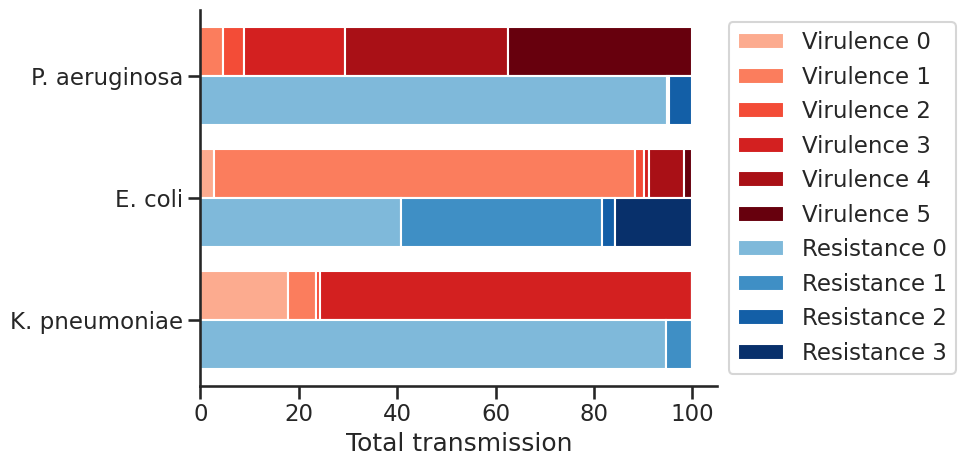

In [186]:
plot_grouped_stacked_bar_vir_res(vir_proportion, amr_proportion)

In [187]:
non_vir_proportion

,dataset,metric,virulence_score,proportion_of_transmission_%
0,K. pneumoniae,transmission_180d,0.0,44.635511
1,K. pneumoniae,transmission_180d,1.0,46.316713
2,K. pneumoniae,transmission_180d,2.0,1.231419
3,K. pneumoniae,transmission_180d,3.0,5.328835
4,K. pneumoniae,transmission_180d,4.0,1.276672
5,K. pneumoniae,transmission_180d,5.0,1.210850
6,E. coli,transmission_180d,0.0,7.214845
7,E. coli,transmission_180d,1.0,61.599742
8,E. coli,transmission_180d,2.0,3.825719
9,E. coli,transmission_180d,3.0,1.612165


In [188]:
non_vir_proportion['virulence_score'] = non_vir_proportion['virulence_score'].astype(int)
non_amr_proportion['resistance_score'] = non_amr_proportion['resistance_score'].astype(int)


def plot_grouped_stacked_bar_non_vir_res(vir_df, res_df):

    fig, ax = plt.subplots(figsize=(10, 5))

    datasets = list(pd.unique(vir_df['dataset'].tolist() + res_df['dataset'].tolist()))
    y_pos_map = {ds: i for i, ds in enumerate(datasets)}
    bar_height = 0.4

    # Ensure correct dtypes
    vir_df['virulence_score'] = vir_df['virulence_score'].astype(int)
    res_df['resistance_score'] = res_df['resistance_score'].astype(float)

    # Color mapping
    vir_max = max(vir_df['virulence_score'].unique())
    res_max = max(res_df['resistance_score'].unique())
    vir_colors = {
        score: plt.cm.Reds(0.3 + 0.7 * (score / vir_max))  # from medium to dark red
        for score in sorted(vir_df['virulence_score'].unique())
    }
    res_colors = {
        score: plt.cm.Blues(0.45 + 0.55 * (score / res_max))  # start at 0.45 to keep even 0 a bit darker
        for score in sorted(res_df['resistance_score'].unique())
    }

    for dataset in datasets:
        if dataset in vir_df['dataset'].values:
            y = y_pos_map[dataset]
            data = vir_df[vir_df['dataset'] == dataset]
            bottom = 0
            for _, row in data.iterrows():
                ax.barh(y + bar_height/2, row['proportion_of_transmission_%'],
                        left=bottom, height=bar_height, color=vir_colors[row['virulence_score']])
                bottom += row['proportion_of_transmission_%']

        if dataset in res_df['dataset'].values:
            y = y_pos_map[dataset]
            data = res_df[res_df['dataset'] == dataset]
            bottom = 0
            for _, row in data.iterrows():
                ax.barh(y - bar_height/2, row['proportion_of_transmission_%'],
                        left=bottom, height=bar_height, color=res_colors[row['resistance_score']])
                bottom += row['proportion_of_transmission_%']

    y_pos = [y_pos_map[ds] for ds in datasets]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(datasets)
    ax.set_xlabel("Total non transmission")
    ax.set_title("")

    vir_legend = [Patch(facecolor=vir_colors[score], label=f"Virulence {score}") for score in sorted(vir_colors.keys())]
    res_legend = [Patch(facecolor=res_colors[score], label=f"Resistance {int(score)}") for score in sorted(res_colors.keys())]
    ax.legend(handles=vir_legend + res_legend, loc='center left', bbox_to_anchor=(1, 0.5), facecolor="white")

    sns.despine()
    plt.tight_layout()
    
    
    plt.savefig(f'../../out/figures/non_transmission_proportion_vir_res.png',
                dpi=150, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/non_transmission_proportion_vir_res.svg',
                dpi=150, bbox_inches='tight', transparent=True, format='svg')

    plt.show();

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

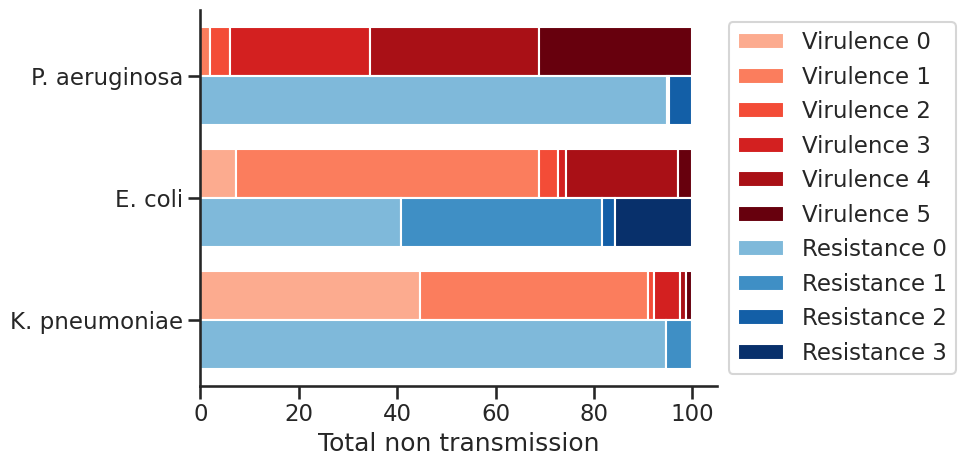

In [189]:
plot_grouped_stacked_bar_non_vir_res(non_vir_proportion, non_amr_proportion)

In [190]:
def plot_grouped_stacked_bar_vir_res(vir_df, res_df):

    fig, ax = plt.subplots(figsize=(10, 5))

    datasets = list(pd.unique(vir_df['dataset'].tolist() + res_df['dataset'].tolist()))
    y_pos_map = {ds: i for i, ds in enumerate(datasets)}
    bar_height = 0.4

    # Ensure correct dtypes
    vir_df['virulence_score'] = vir_df['virulence_score'].astype(int)
    res_df['resistance_score'] = res_df['resistance_score'].astype(float)

    # Color mapping
    vir_max = max(vir_df['virulence_score'].unique())
    res_max = max(res_df['resistance_score'].unique())
    vir_colors = {
        score: plt.cm.Reds(0.3 + 0.7 * (score / vir_max))  # from medium to dark red
        for score in sorted(vir_df['virulence_score'].unique())
    }
    res_colors = {
        score: plt.cm.Blues(0.45 + 0.55 * (score / res_max))  # start at 0.45 to keep even 0 a bit darker
        for score in sorted(res_df['resistance_score'].unique())
    }

    for dataset in datasets:
        if dataset in vir_df['dataset'].values:
            y = y_pos_map[dataset]
            data = vir_df[vir_df['dataset'] == dataset]
            bottom = 0
            for _, row in data.iterrows():
                ax.barh(y + bar_height/2, row['proportion_of_transmission_%'],
                        left=bottom, height=bar_height, color=vir_colors[row['virulence_score']])
                bottom += row['proportion_of_transmission_%']

        if dataset in res_df['dataset'].values:
            y = y_pos_map[dataset]
            data = res_df[res_df['dataset'] == dataset]
            bottom = 0
            for _, row in data.iterrows():
                ax.barh(y - bar_height/2, row['proportion_of_transmission_%'],
                        left=bottom, height=bar_height, color=res_colors[row['resistance_score']])
                bottom += row['proportion_of_transmission_%']

    y_pos = [y_pos_map[ds] for ds in datasets]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(datasets)
    ax.set_xlabel("Total transmission")
    ax.set_title("")

    vir_legend = [Patch(facecolor=vir_colors[score], label=f"Virulence {score}") for score in sorted(vir_colors.keys())]
    res_legend = [Patch(facecolor=res_colors[score], label=f"Resistance {int(score)}") for score in sorted(res_colors.keys())]
    ax.legend(handles=vir_legend + res_legend, loc='center left', bbox_to_anchor=(1, 0.5), facecolor="white")

    sns.despine()
    plt.tight_layout()
    
    
    plt.savefig(f'../../out/figures/nontransmission_proportion_vir_res.png',
                dpi=150, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/nontransmission_proportion_vir_res.svg',
                dpi=150, bbox_inches='tight', transparent=True, format='svg')

    plt.show();

In [191]:
sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

# Color and alpha mappings
species_order = ["K. pneumoniae", "E. coli", "P. aeruginosa"]
species_colors = {
    "K. pneumoniae": "xkcd:orange",
    "E. coli": "xkcd:dodger blue",
    "P. aeruginosa": "xkcd:violet"
}
alpha_map = {
    "transmission_180d": 1.0,
    "transmission_20SNP": 0.5
}
df_filtered["color"] = df_filtered["species"].map(species_colors)
df_filtered["alpha"] = df_filtered["metric"].map(alpha_map)

# Plot
plt.figure(figsize=(7 , 4))

# Bar positioning
x_offset = {"transmission_180d": -0.2, "transmission_20SNP": 0.2}
bar_height = 0.4

for metric in ["transmission_180d", "transmission_20SNP"]:
    subset = df_filtered[df_filtered["metric"] == metric]
    for i, species in enumerate(species_order):
        val = subset[subset["species"] == species]["value"].values[0]
        color = species_colors[species]
        alpha = alpha_map[metric]
        plt.barh(
            y=len(species_order) - 1 - i + x_offset[metric],  # reversed for top-down order
            width=val,
            height=bar_height,
            color=color,
            alpha=alpha,
            edgecolor="black",
            label=metric if i == 0 else ""
        )

plt.yticks(range(len(species_order)), species_order)
plt.xlabel("Proportion transmission")
plt.ylabel("")
plt.legend(title="Metric", facecolor="white")
plt.tight_layout()

<ipython-input-191-45dab581314e>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["color"] = df_filtered["species"].map(species_colors)
<ipython-input-191-45dab581314e>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["alpha"] = df_filtered["metric"].map(alpha_map)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: 

In [192]:
def transmission_by_score(df1, df2, df3, 
                          df1_name='df1', df2_name='df2', df3_name='df3',
                          score_cols=['virulence_score', 'resistance_score'],
                          transmission_cols=['transmission_180d', 'transmission_20SNP']):
    
    def compute_group(df, score_col, species_name):
        grouped = (
            df.groupby(score_col)[transmission_cols]
            .apply(lambda g: (g == 1).mean() * 100)
            .reset_index()
        )
        grouped['species'] = species_name
        grouped['score_type'] = score_col
        return grouped

    results = pd.concat([
        *[compute_group(df1, col, df1_name) for col in score_cols],
        *[compute_group(df2, col, df2_name) for col in score_cols],
        *[compute_group(df3, col, df3_name) for col in score_cols],
    ])

    return results[['species', 'score_type'] + score_cols + transmission_cols]

In [193]:
transmission_scores_summary = transmission_by_score(tekp_h, teec_h, tepa_h,
                     df1_name="K. pneumoniae", df2_name="E. coli", df3_name="P. aeruginosa")

In [203]:
non_vir_proportion

,dataset,metric,virulence_score,proportion_of_transmission_%
0,K. pneumoniae,transmission_180d,0,44.635511
1,K. pneumoniae,transmission_180d,1,46.316713
2,K. pneumoniae,transmission_180d,2,1.231419
3,K. pneumoniae,transmission_180d,3,5.328835
4,K. pneumoniae,transmission_180d,4,1.276672
5,K. pneumoniae,transmission_180d,5,1.210850
6,E. coli,transmission_180d,0,7.214845
7,E. coli,transmission_180d,1,61.599742
8,E. coli,transmission_180d,2,3.825719
9,E. coli,transmission_180d,3,1.612165


In [201]:
vir_proportion

,dataset,metric,virulence_score,proportion_of_transmission_%
0,K. pneumoniae,transmission_180d,0,17.817713
1,K. pneumoniae,transmission_180d,1,5.665243
2,K. pneumoniae,transmission_180d,2,0.749456
3,K. pneumoniae,transmission_180d,3,75.711177
4,K. pneumoniae,transmission_180d,4,0.032235
5,K. pneumoniae,transmission_180d,5,0.024176
6,E. coli,transmission_180d,0,2.756340
7,E. coli,transmission_180d,1,85.539819
8,E. coli,transmission_180d,2,1.823425
9,E. coli,transmission_180d,3,1.119498


In [205]:
vir = non_vir_proportion.merge(
    vir_proportion, 
    on=['dataset', 'virulence_score', 'metric'], 
    suffixes=('_non_vir', '_vir')
)

amr = non_amr_proportion.merge(amr_proportion, on=["dataset", "resistance_score", "metric"],
                              suffixes=("_non_amr", "_amr"))

In [209]:
amr

,dataset,metric,resistance_score,proportion_of_transmission_%_non_amr,proportion_of_transmission_%_amr
0,K. pneumoniae,transmission_180d,0.0,94.705456,94.705456
1,K. pneumoniae,transmission_180d,1.0,5.125312,5.125312
2,K. pneumoniae,transmission_180d,2.0,0.169232,0.169232
3,E. coli,transmission_180d,0.0,40.810788,40.810788
4,E. coli,transmission_180d,1.0,40.904079,40.904079
5,E. coli,transmission_180d,2.0,2.637605,2.637605
6,E. coli,transmission_180d,3.0,15.647528,15.647528
7,P. aeruginosa,transmission_180d,0.0,94.762590,94.762590
8,P. aeruginosa,transmission_180d,1.0,0.417266,0.417266
9,P. aeruginosa,transmission_180d,2.0,4.820144,4.820144


In [206]:
def significance_vir(row):
    count_non_vir = row['proportion_of_transmission_%_non_vir']
    count_vir = row['proportion_of_transmission_%_vir']
    count_other_non_vir = 100 - count_non_vir
    count_other_vir = 100 - count_vir
    
    from scipy.stats import chi2_contingency
    table = [[count_non_vir, count_other_non_vir],
             [count_vir, count_other_vir]]
    
    chi2, p, _, _ = chi2_contingency(table)
    return p

vir['p_value'] = vir.apply(significance_vir, axis=1)


In [210]:
def significance_amr(row):
    count_non_amr = row['proportion_of_transmission_%_non_amr']
    count_amr = row['proportion_of_transmission_%_amr']
    count_other_non_amr = 100 - count_non_amr
    count_other_amr = 100 - count_amr
    
    from scipy.stats import chi2_contingency
    table = [[count_non_amr, count_other_non_amr],
             [count_amr, count_other_amr]]
    
    chi2, p, _, _ = chi2_contingency(table)
    return p

amr['p_value'] = amr.apply(significance_amr, axis=1)

In [243]:
sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

def plot_comparison(df, score_col, prop_non_col, prop_vir_col, p_col, metric_name, colors_dict, title="Comparison", x_name=""):
    """
    df: merged DataFrame
    score_col: str, column with scores (virulence_score or resistance_score)
    prop_non_col: str, column with non_vir / non_amr proportions
    prop_vir_col: str, column with vir / amr proportions
    p_col: str, column with p-values for significance
    metric_name: str, 'Virulence' or 'Resistance'
    colors_dict: dict, {score: color}
    """
    # Determine full range of scores
    if 'virulence' in score_col:
        full_scores = list(range(0, 6))  # 0-5
    elif 'resistance' in score_col:
        full_scores = list(range(0, 4))  # 0-3
    else:
        full_scores = sorted(df[score_col].unique())

    species_list = df['dataset'].unique()
    fig, axes = plt.subplots(1, len(species_list), figsize=(12, 4), sharey=True)

    if len(species_list) == 1:
        axes = [axes]  # ensure axes is iterable

    for ax, species in zip(axes, species_list):
        data = df[df['dataset'] == species]
        # Fill in missing scores with zeros
        filled_data = pd.DataFrame({score_col: full_scores})
        filled_data = filled_data.merge(data, on=score_col, how='left')
        # Fill missing values
        filled_data[prop_non_col] = filled_data[prop_non_col].fillna(0)
        filled_data[prop_vir_col] = filled_data[prop_vir_col].fillna(0)
        filled_data[p_col] = filled_data[p_col].fillna(1)  # p=1 for non-significant

        scores = filled_data[score_col].tolist()
        non_props = filled_data[prop_non_col].tolist()
        vir_props = filled_data[prop_vir_col].tolist()
        p_values = filled_data[p_col].tolist()
        
        bar_width = 0.35
        x = np.arange(len(scores))
        
        # Plot non_vir / non_amr bars
        ax.bar(x - bar_width/2, non_props, width=bar_width, color=[colors_dict[s] for s in scores], label=f'Non {metric_name}')
        ax.bar(x + bar_width/2, vir_props, width=bar_width, color=[colors_dict[s] for s in scores], alpha=0.5, label=f'{metric_name}')
        
        # Add nicer significance lines and stars
        for xi, p in zip(x, p_values):
            if p < 0.05:
                y_max = max(non_props[xi], vir_props[xi])
                line_height = y_max + 3  # some space above bar
                star_offset = 1  # space for the stars above the line

                # Draw horizontal line
                ax.hlines(line_height, xi - bar_width/2, xi + bar_width/2, color='black', lw=1.5)
                # Draw short vertical ticks at ends
                ax.vlines([xi - bar_width/2, xi + bar_width/2], line_height - 0.5, line_height, color='black', lw=1.5)

                # Determine stars
                if p < 0.0001:
                    stars = '****'
                elif p < 0.001:
                    stars = '***'
                elif p < 0.01:
                    stars = '**'
                else:
                    stars = '*'
                ax.text(xi, line_height + star_offset, stars, ha='center', va='bottom', fontsize=12, color='black')
        
        ax.set_xticks(x)
        ax.set_xticklabels(scores)
        ax.set_xlabel(f'{x_name} Score')
        ax.set_title(r"$\it{" + species + "}$")
        ax.set_ylabel('% strains')
        ax.set_ylim(0, 100)  # Set y-axis from 0 to 100
        ax.legend()

    plt.suptitle(title)
    plt.tight_layout()
    # Save figures
    plt.savefig(f'../../out/figures/score_{x_name}.png',
                dpi=150, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/score_{x_name}.svg',
                dpi=150, bbox_inches='tight', transparent=True, format='svg')
    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

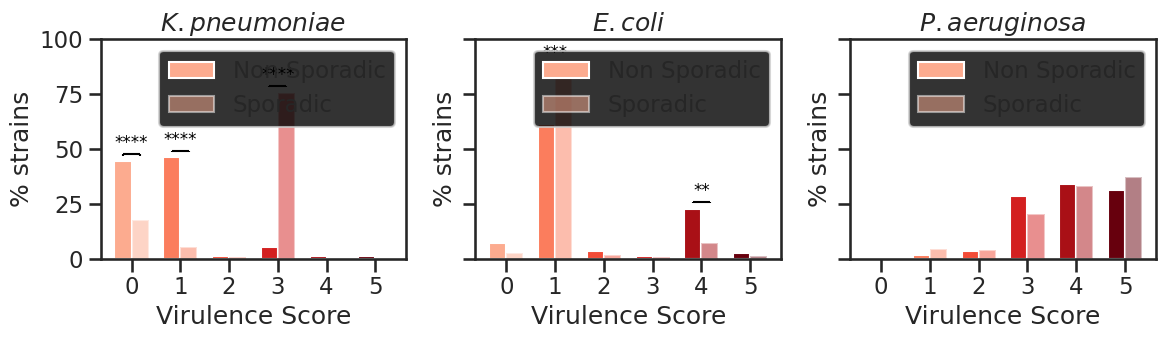

In [244]:
vir_max = vir['virulence_score'].max()
vir_colors = {
    score: plt.cm.Reds(0.3 + 0.7 * (score / vir_max))
    for score in sorted(vir['virulence_score'].unique())
}

plot_comparison(
    df=vir,
    score_col='virulence_score',
    prop_non_col='proportion_of_transmission_%_non_vir',
    prop_vir_col='proportion_of_transmission_%_vir',
    p_col='p_value',
    metric_name='Sporadic',
    x_name="Virulence",
    colors_dict=vir_colors,
    title=''
)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

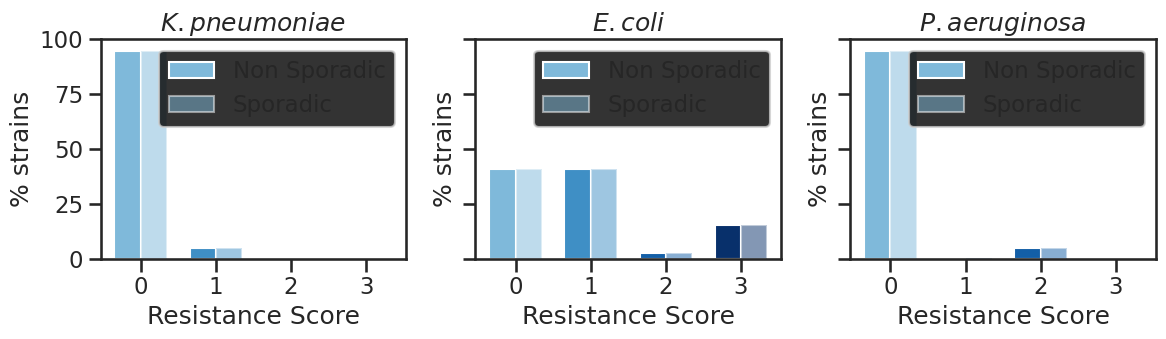

In [245]:
res_max = amr['resistance_score'].max()
res_colors = {
    score: plt.cm.Blues(0.45 + 0.55 * (score / res_max))
    for score in sorted(amr['resistance_score'].unique())
}

plot_comparison(
    df=amr,
    score_col='resistance_score',
    prop_non_col='proportion_of_transmission_%_non_amr',
    prop_vir_col='proportion_of_transmission_%_amr',
    p_col='p_value',
    metric_name="Sporadic",
    x_name='Resistance',
    colors_dict=res_colors,
    title=''
)